# Chapter 4 — Model Evaluation

**Project:** Policyholder Risk Stratification and Claim Probability Prediction

**Dataset:** Porto Seguro Safe Driver Prediction (Kaggle)

**Author:** Whitney Kemuma

---

### Chapter Overview

This chapter provides a comprehensive evaluation of the three models trained
in Chapter 3. All models are evaluated on the held out test set data that
was never seen during training or cross validation.

| Section | Activity |
|---------|----------|
| 4.1 | Load models and data |
| 4.2 | Metrics table — Accuracy, Precision, Recall, F1, AUC |
| 4.3 | Confusion matrices — all 3 models side by side |
| 4.4 | ROC curves — all 3 models on one plot |
| 4.5 | Cross-validation score comparison |
| 4.6 | Feature importance plots |
| 4.7 | Evaluation summary and research findings |

### Evaluation Strategy

| Metric | Why It Matters Here |
|--------|---------------------|
| AUC-ROC | Primary metric — measures discrimination ability across all thresholds, unaffected by class imbalance |
| Recall | Critical for insurance — measures how many actual claims the model correctly identifies |
| Precision | Measures how many predicted claims are real — controls false alarm rate |
| F1-Score | Harmonic mean of precision and recall — balances both for imbalanced data |
| Accuracy | Reported for completeness — less meaningful on imbalanced datasets |

> **Research connection:** Results directly answer RQ1 (which model performs
> best?) and RQ2 (which features drive predictions?) from Chapter 0.

---


# ── 4.1 IMPORTS AND LOAD ─────────────────────────────────────
### 4.1 Import Libraries and Load Models

Trained models are loaded from the `models/` folder saved by Chapter 3.
Test data is loaded from the compressed files saved by Chapter 1.
This chapter performs no training only evaluation.


In [2]:
# ── Standard libraries ───────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.size']        = 11
plt.rcParams['axes.titlesize']   = 12
plt.rcParams['axes.titleweight'] = 'bold'

# ── Evaluation metrics ────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# ── Import from src ───────────────────────────────────────────
sys.path.append('../src')
from data_loader  import load_cleaned_data, scale_features
from model_utils  import load_all_models, get_predictions

print(" Libraries imported successfully.")


 Libraries imported successfully.


In [3]:
# ── Load test data ────────────────────────────────────────────
data = load_cleaned_data('../data')

X_test  = data['X_test']
y_test  = data['y_test']
X_train = data['X_train']
y_train = data['y_train']
df      = data['df']

# ── Load scaler and apply to test data ───────────────────────
# Scaler was fit on training data in Chapter 3
# Must apply same transformation to test data for Logistic Regression
_, X_test_scaled, _ = scale_features(X_train, X_test)

print(f"\\n Test set loaded.")
print(f"   Test samples : {X_test.shape[0]:,}")
print(f"   Features     : {X_test.shape[1]}")


 Loading cleaned data from data folder...
 Cleaned data loaded.
   Full dataset : (595212, 206)
   X_train      : (476169, 205)
   X_test       : (119043, 205)
   y_train      : (476169,)
   y_test       : (119043,)
 Scaling complete.
   Fit on training data only (no data leakage)
\n Test set loaded.
   Test samples : 119,043
   Features     : 205


In [4]:
# ── Load trained models from Chapter 3 ───────────────────────
models = load_all_models('../models')

lr_model  = models['lr_model']
rf_model  = models['rf_model']
xgb_model = models['xgb_model']

# ── Generate predictions for all models ──────────────────────
preds = get_predictions(models, X_test, X_test_scaled)

lr_pred  = preds['lr_pred']   ; lr_proba  = preds['lr_proba']
rf_pred  = preds['rf_pred']   ; rf_proba  = preds['rf_proba']
xgb_pred = preds['xgb_pred']  ; xgb_proba = preds['xgb_proba']

# ── Set up output path for saving plots ──────────────────────
DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data')

print("\\n All models loaded and predictions generated.")
print("   Ready for evaluation.")


 All models loaded from models/ folder.
   lr_model     ← logistic_regression.pkl
   rf_model     ← random_forest.pkl
   xgb_model    ← xgboost.pkl
   scaler       ← scaler.pkl
\n All models loaded and predictions generated.
   Ready for evaluation.


# ── 4.2 METRICS TABLE ────────────────────────────────────────
### 4.2 Performance Metrics Table

All five metrics are computed for each model on the held-out test set.
This provides the primary quantitative answer to RQ1 — which model
performs best for insurance claim prediction?

**Interpretation guide:**
- Higher AUC-ROC = better overall discrimination
- Higher Recall = fewer missed claims (most important in insurance)
- Higher Precision = fewer false alarms
- F1 balances precision and recall — most useful summary for imbalanced data
  

In [6]:
# ── Compute all metrics for each model ───────────────────────
def compute_metrics(name, y_true, y_pred, y_proba):
    """Compute and return all evaluation metrics for one model."""
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_true, y_proba), 4)
    }

metrics_table = pd.DataFrame([
    compute_metrics('Logistic Regression', y_test, lr_pred,  lr_proba),
    compute_metrics('Random Forest',       y_test, rf_pred,  rf_proba),
    compute_metrics('XGBoost',             y_test, xgb_pred, xgb_proba)
])

print(" Model Performance — Test Set Results:")
print("=" * 65)
print(metrics_table.to_string(index=False))
print("=" * 65)

# ── Highlight best value per metric ──────────────────────────
print("\\n Best per metric:")
for col in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    best_idx = metrics_table[col].idxmax()
    best_val = metrics_table[col].max()
    best_mod = metrics_table.loc[best_idx, 'Model']
    print(f"   {col:<12}: {best_mod} ({best_val})")


 Model Performance — Test Set Results:
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.6214     0.0530  0.5568    0.0968   0.6272
      Random Forest    0.8780     0.0642  0.1729    0.0936   0.6076
            XGBoost    0.6657     0.0565  0.5204    0.1019   0.6343
\n Best per metric:
   Accuracy    : Random Forest (0.878)
   Precision   : Random Forest (0.0642)
   Recall      : Logistic Regression (0.5568)
   F1-Score    : XGBoost (0.1019)
   AUC-ROC     : XGBoost (0.6343)


In [7]:
# ── Save metrics table to data folder ────────────────────────
metrics_path = os.path.join(DATA_PATH, 'model_metrics.csv')
metrics_table.to_csv(metrics_path, index=False)
print(f" Metrics table saved → {metrics_path}")


 Metrics table saved → C:\Users\Administrator\Desktop\policyholder-risk-predictions\data\model_metrics.csv


# ── 4.3 CONFUSION MATRICES ───────────────────────────────────
### 4.3 Confusion Matrices

A confusion matrix shows the breakdown of correct and incorrect predictions
into four categories for each model. In the insurance context:

| Cell | Meaning | Business Impact |
|------|---------|-----------------|
| True Negative (TN) | Correctly predicted no claim |  Accurate pricing |
| True Positive (TP) | Correctly predicted claim |  Risk correctly flagged |
| False Positive (FP) | Predicted claim — no claim filed |  Unnecessary intervention |
| False Negative (FN) | Missed claim — predicted no claim |  Most costly — undetected risk |

> **Key insight for insurance:** False Negatives are the most costly error.
> A policyholder incorrectly classified as low-risk may be under-priced,
> leading to an unexpected claim that was not reserved for.


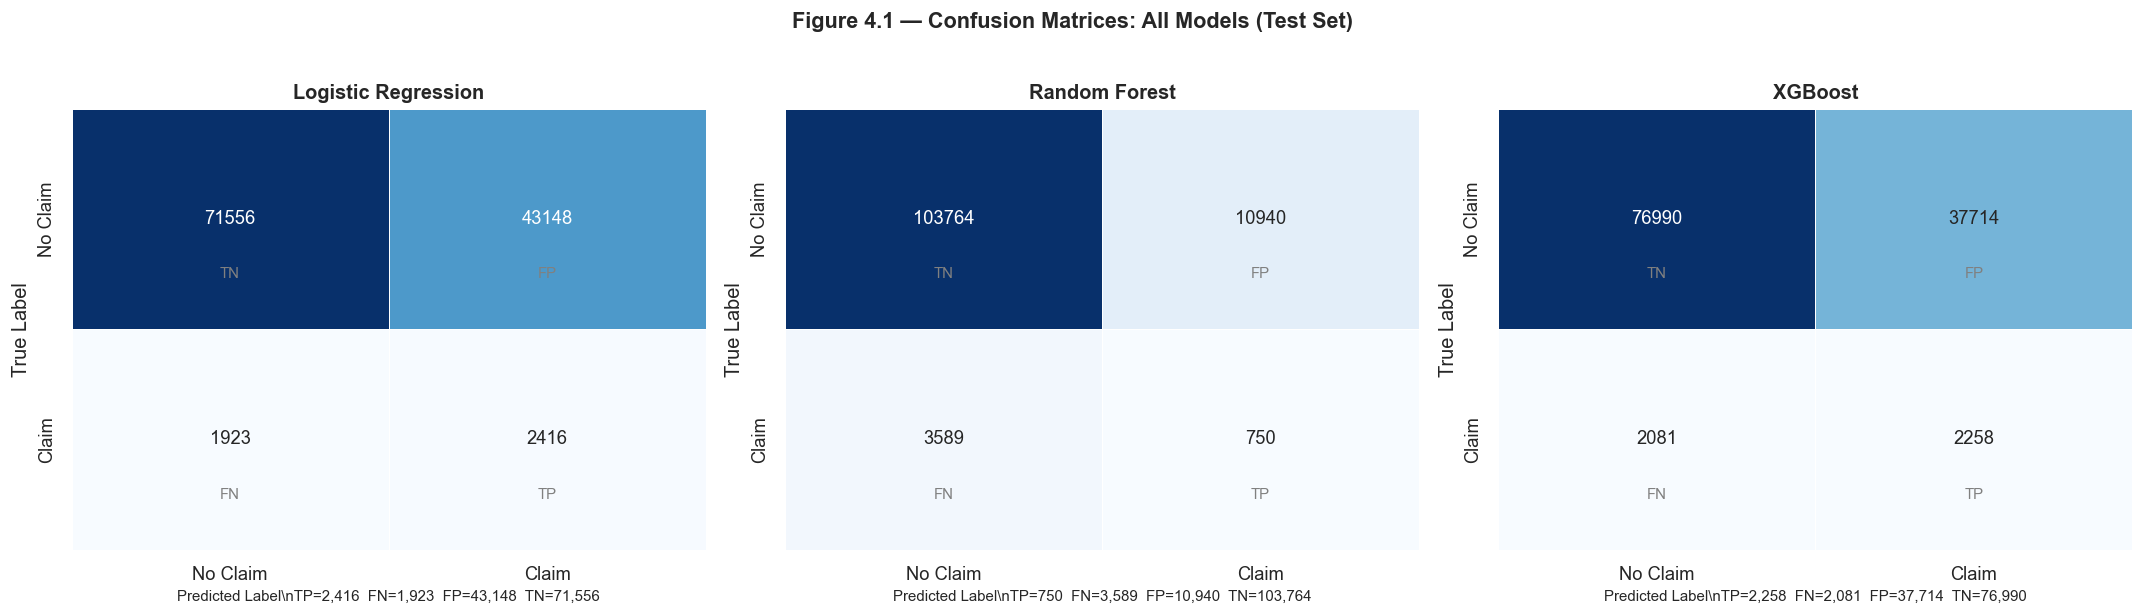

 Saved → data/fig4_1_confusion_matrices.png


In [8]:
# ── Plot confusion matrices — all 3 models side by side ───────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_info = [
    ('Logistic Regression', lr_pred,  '#3498db'),
    ('Random Forest',       rf_pred,  '#2ecc71'),
    ('XGBoost',             xgb_pred, '#e74c3c')
]

for ax, (name, pred, color) in zip(axes, model_info):
    cm = confusion_matrix(y_test, pred)

    # Plot heatmap
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['No Claim', 'Claim'],
        yticklabels=['No Claim', 'Claim'],
        linewidths=0.5,
        cbar=False
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    # Annotate with TN/FP/FN/TP labels
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(
                j + 0.5, i + 0.75,
                labels[i][j],
                ha='center', va='center',
                fontsize=9, color='grey'
            )

    # Print key stats below each matrix
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(
        f'Predicted Label\\nTP={tp:,}  FN={fn:,}  FP={fp:,}  TN={tn:,}',
        fontsize=9
    )

plt.suptitle(
    'Figure 4.1 — Confusion Matrices: All Models (Test Set)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    os.path.join(DATA_PATH, 'fig4_1_confusion_matrices.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Saved → data/fig4_1_confusion_matrices.png")


# ── 4.4 ROC CURVES ───────────────────────────────────────────
### 4.4 ROC Curves

The ROC (Receiver Operating Characteristic) curve plots the True Positive
Rate against the False Positive Rate at every possible classification
threshold. The Area Under the Curve (AUC) summarises performance in a
single number — 1.0 is perfect, 0.5 is no better than random guessing.

ROC-AUC is the primary evaluation metric for this study because it:
- Is threshold-independent — evaluates the full probability ranking
- Is unaffected by class imbalance — unlike accuracy
- Is standard in insurance claim prediction literature


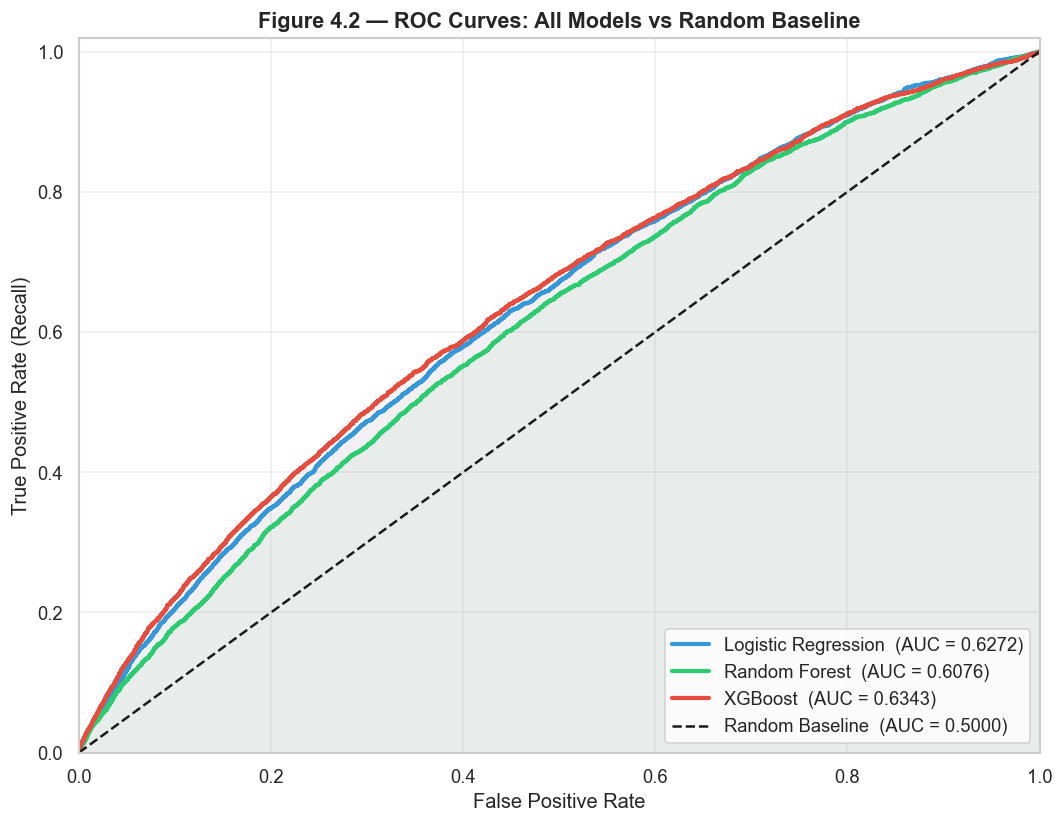

 Saved → data/fig4_2_roc_curves.png


In [9]:
# ── Plot ROC curves — all 3 models on one chart ───────────────
fig, ax = plt.subplots(figsize=(9, 7))

colors     = ['#3498db', '#2ecc71', '#e74c3c']
model_data = [
    ('Logistic Regression', lr_proba),
    ('Random Forest',       rf_proba),
    ('XGBoost',             xgb_proba)
]

for (name, proba), color in zip(model_data, colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc         = roc_auc_score(y_test, proba)
    ax.plot(
        fpr, tpr,
        label=f'{name}  (AUC = {auc:.4f})',
        color=color,
        linewidth=2.5
    )
    # Shade area under curve
    ax.fill_between(fpr, tpr, alpha=0.05, color=color)

# Random baseline
ax.plot(
    [0, 1], [0, 1],
    'k--', linewidth=1.5,
    label='Random Baseline  (AUC = 0.5000)'
)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title(
    'Figure 4.2 — ROC Curves: All Models vs Random Baseline',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(
    os.path.join(DATA_PATH, 'fig4_2_roc_curves.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Saved → data/fig4_2_roc_curves.png")


# ── 4.5 CROSS-VALIDATION COMPARISON ─────────────────────────
### 4.5 Cross-Validation Score Comparison

Cross-validation scores from Chapter 3 are visualised here for comparison.
The CV scores represent performance on training data across 5 folds,
comparing these to test set AUC confirms whether models generalise well
or show signs of overfitting.

**What to look for:**
- CV AUC ≈ Test AUC → model generalises well 
- CV AUC >> Test AUC → model may be overfitting 
- Low std across folds → stable, reliable model 


In [10]:
# ── Load CV scores saved by Chapter 3 ────────────────────────
# Re-run CV here to get scores for plotting
# (Faster than full training — just scoring)
from sklearn.model_selection import StratifiedKFold, cross_val_score

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(" Computing CV scores for comparison plot...")
print("   (Uses same CV strategy as Chapter 3)")

_, X_train_scaled, _ = scale_features(X_test, X_train)

lr_cv = cross_val_score(
    lr_model, X_train_scaled, y_train,
    cv=CV, scoring='roc_auc', n_jobs=-1
)
rf_cv = cross_val_score(
    rf_model, X_train, y_train,
    cv=CV, scoring='roc_auc', n_jobs=-1
)
xgb_cv = cross_val_score(
    xgb_model, X_train, y_train,
    cv=CV, scoring='roc_auc', n_jobs=-1
)

print(" CV scores computed.")


 Computing CV scores for comparison plot...
   (Uses same CV strategy as Chapter 3)
 Scaling complete.
   Fit on training data only (no data leakage)
 CV scores computed.


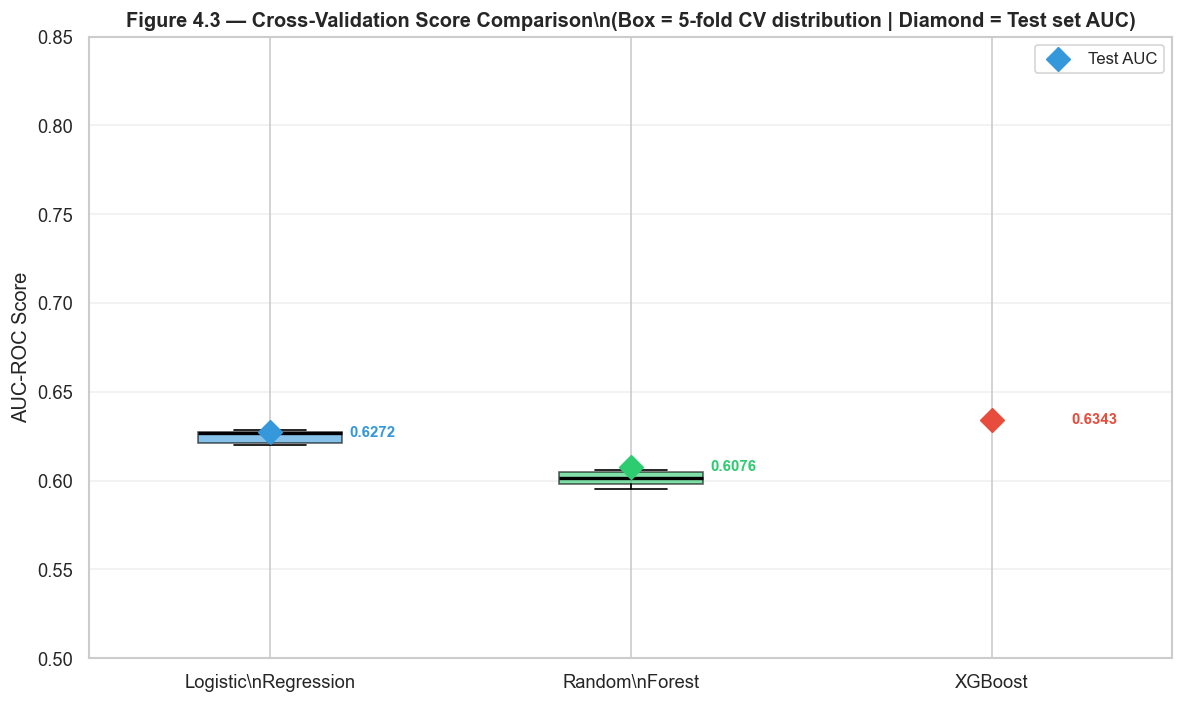

 Saved → data/fig4_3_cv_comparison.png


In [11]:
# ── Plot CV score comparison — boxplot + test AUC overlay ────
fig, ax = plt.subplots(figsize=(10, 6))

cv_data    = [lr_cv, rf_cv, xgb_cv]
model_names = ['Logistic\\nRegression', 'Random\\nForest', 'XGBoost']
colors      = ['#3498db', '#2ecc71', '#e74c3c']
test_aucs   = [
    roc_auc_score(y_test, lr_proba),
    roc_auc_score(y_test, rf_proba),
    roc_auc_score(y_test, xgb_proba)
]

# Boxplot of CV fold scores
bp = ax.boxplot(
    cv_data,
    labels=model_names,
    patch_artist=True,
    widths=0.4,
    medianprops=dict(color='black', linewidth=2)
)

# Colour each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Overlay test AUC as a diamond marker
for i, (test_auc, color) in enumerate(zip(test_aucs, colors), 1):
    ax.scatter(
        i, test_auc,
        marker='D', s=100,
        color=color, zorder=5,
        label=f'Test AUC' if i == 1 else ''
    )
    ax.text(
        i + 0.22, test_auc,
        f'{test_auc:.4f}',
        va='center', fontsize=9, color=color,
        fontweight='bold'
    )

ax.set_ylabel('AUC-ROC Score', fontsize=12)
ax.set_title(
    'Figure 4.3 — Cross-Validation Score Comparison\\n'
    '(Box = 5-fold CV distribution | Diamond = Test set AUC)',
    fontsize=12, fontweight='bold'
)
ax.set_ylim([0.5, 0.85])
ax.grid(True, axis='y', alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(
    os.path.join(DATA_PATH, 'fig4_3_cv_comparison.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Saved → data/fig4_3_cv_comparison.png")


# ── 4.6 FEATURE IMPORTANCE ───────────────────────────────────
### 4.6 Feature Importance

Feature importance is examined from two perspectives:

**Logistic Regression — Coefficients**
The magnitude of each coefficient indicates how strongly that feature
influences the log-odds of a claim. Positive coefficients increase claim
probability; negative coefficients decrease it.

**Random Forest and XGBoost — Feature Importance Scores**
Both tree models provide a built-in importance score based on how frequently
and effectively each feature is used to split nodes across all trees.
Higher importance = greater contribution to prediction accuracy.

> **Research connection:** These plots directly answer RQ2 from Chapter 0 —
> which policyholder features are the strongest predictors of claim probability?
                  

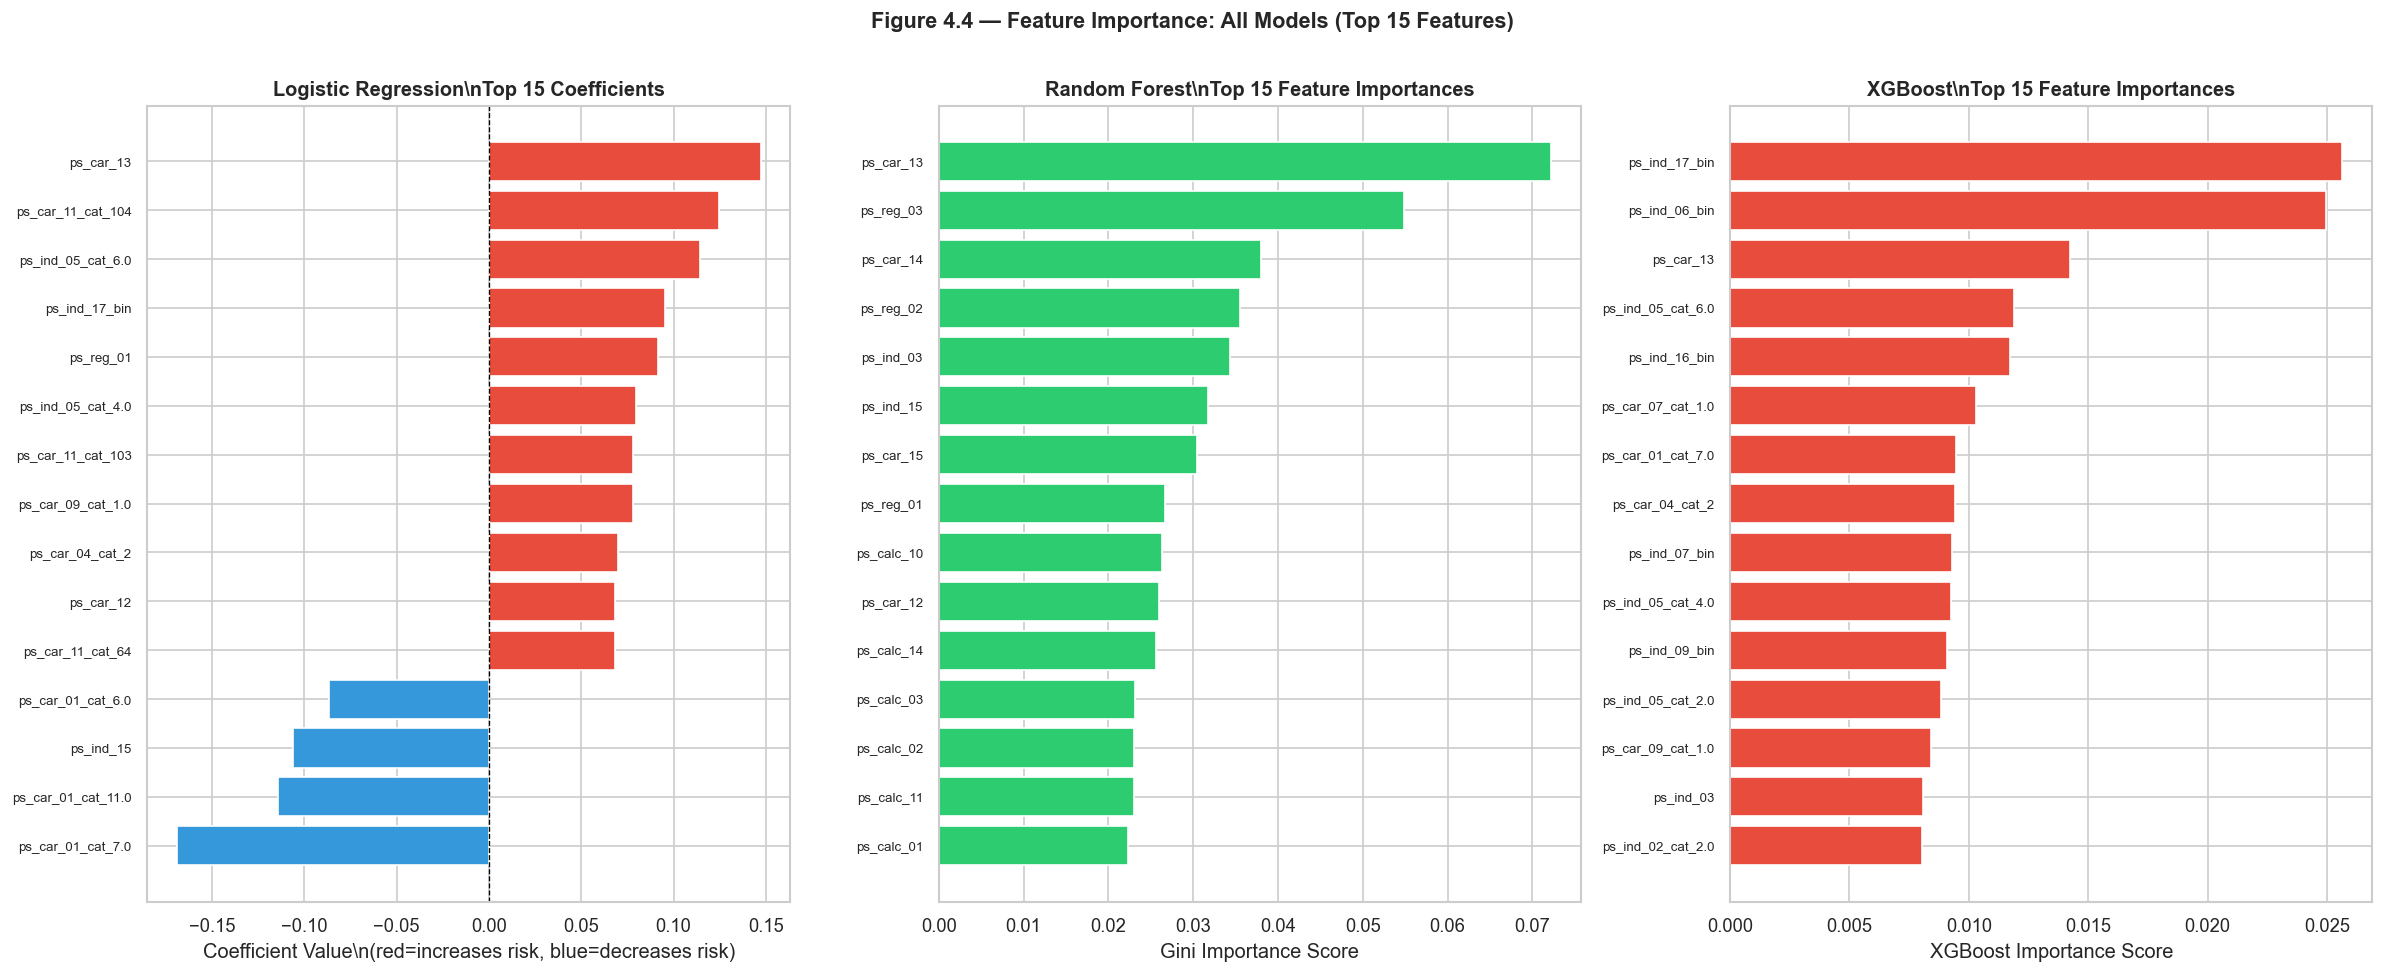

 Saved → data/fig4_4_feature_importance.png


In [12]:
# ── Feature names ─────────────────────────────────────────────
feature_names = X_test.columns.tolist()

# ── Figure: 3 importance plots side by side ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# ── Plot 1: Logistic Regression coefficients ──────────────────
lr_coef    = pd.Series(lr_model.coef_[0], index=feature_names)
top_lr     = lr_coef.abs().sort_values(ascending=False).head(15)
lr_plot    = lr_coef[top_lr.index].sort_values()
bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in lr_plot.values]

axes[0].barh(
    range(len(lr_plot)), lr_plot.values,
    color=bar_colors, edgecolor='white'
)
axes[0].set_yticks(range(len(lr_plot)))
axes[0].set_yticklabels(lr_plot.index, fontsize=8)
axes[0].set_title('Logistic Regression\\nTop 15 Coefficients')
axes[0].set_xlabel('Coefficient Value\\n(red=increases risk, blue=decreases risk)')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')

# ── Plot 2: Random Forest feature importance ──────────────────
rf_importance = pd.Series(
    rf_model.feature_importances_, index=feature_names
).sort_values(ascending=False).head(15).sort_values()

axes[1].barh(
    range(len(rf_importance)), rf_importance.values,
    color='#2ecc71', edgecolor='white'
)
axes[1].set_yticks(range(len(rf_importance)))
axes[1].set_yticklabels(rf_importance.index, fontsize=8)
axes[1].set_title('Random Forest\\nTop 15 Feature Importances')
axes[1].set_xlabel('Gini Importance Score')

# ── Plot 3: XGBoost feature importance ────────────────────────
xgb_importance = pd.Series(
    xgb_model.feature_importances_, index=feature_names
).sort_values(ascending=False).head(15).sort_values()

axes[2].barh(
    range(len(xgb_importance)), xgb_importance.values,
    color='#e74c3c', edgecolor='white'
)
axes[2].set_yticks(range(len(xgb_importance)))
axes[2].set_yticklabels(xgb_importance.index, fontsize=8)
axes[2].set_title('XGBoost\\nTop 15 Feature Importances')
axes[2].set_xlabel('XGBoost Importance Score')

plt.suptitle(
    'Figure 4.4 — Feature Importance: All Models (Top 15 Features)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    os.path.join(DATA_PATH, 'fig4_4_feature_importance.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Saved → data/fig4_4_feature_importance.png")


In [13]:
# ── Top 10 features per model — tabular view ─────────────────
print(" Top 10 Most Important Features per Model:")
print("=" * 65)

print("\\n Logistic Regression (by absolute coefficient):")
top_lr_tab = lr_coef.abs().sort_values(ascending=False).head(10)
for i, (feat, val) in enumerate(top_lr_tab.items(), 1):
    direction = '↑ increases risk' if lr_coef[feat] > 0 else '↓ decreases risk'
    print(f"   {i:>2}. {feat:<35} {val:.4f}  {direction}")

print("\\n Random Forest (by Gini importance):")
top_rf_tab = pd.Series(
    rf_model.feature_importances_, index=feature_names
).sort_values(ascending=False).head(10)
for i, (feat, val) in enumerate(top_rf_tab.items(), 1):
    print(f"   {i:>2}. {feat:<35} {val:.4f}")

print("\\n XGBoost (by XGBoost importance):")
top_xgb_tab = pd.Series(
    xgb_model.feature_importances_, index=feature_names
).sort_values(ascending=False).head(10)
for i, (feat, val) in enumerate(top_xgb_tab.items(), 1):
    print(f"   {i:>2}. {feat:<35} {val:.4f}")


 Top 10 Most Important Features per Model:
\n Logistic Regression (by absolute coefficient):
    1. ps_car_01_cat_7.0                   0.1691  ↓ decreases risk
    2. ps_car_13                           0.1471  ↑ increases risk
    3. ps_car_11_cat_104                   0.1243  ↑ increases risk
    4. ps_ind_05_cat_6.0                   0.1143  ↑ increases risk
    5. ps_car_01_cat_11.0                  0.1140  ↓ decreases risk
    6. ps_ind_15                           0.1063  ↓ decreases risk
    7. ps_ind_17_bin                       0.0952  ↑ increases risk
    8. ps_reg_01                           0.0917  ↑ increases risk
    9. ps_car_01_cat_6.0                   0.0865  ↓ decreases risk
   10. ps_ind_05_cat_4.0                   0.0795  ↑ increases risk
\n Random Forest (by Gini importance):
    1. ps_car_13                           0.0721
    2. ps_reg_03                           0.0548
    3. ps_car_14                           0.0380
    4. ps_reg_02                      

# ── 4.7 SUMMARY ──────────────────────────────────────────────
### 4.7 Evaluation Summary and Research Findings

This section synthesises the evaluation results into structured research
findings that directly answer the research questions posed in Chapter 0.


In [14]:
# ── Final metrics table ───────────────────────────────────────
print("=" * 65)
print("  CHAPTER 4 COMPLETE — EVALUATION SUMMARY")
print("=" * 65)

print("\\n Final Performance Table (Test Set):")
print(metrics_table.to_string(index=False))

# ── Identify best model overall ──────────────────────────────
best_auc_idx   = metrics_table['AUC-ROC'].idxmax()
best_recall_idx = metrics_table['Recall'].idxmax()
best_f1_idx    = metrics_table['F1-Score'].idxmax()

print(f"""
 Research Findings:

  RQ1 — Best performing model:
  ├── Highest AUC-ROC  : {metrics_table.loc[best_auc_idx, 'Model']}
  │                      ({metrics_table.loc[best_auc_idx, 'AUC-ROC']})
  ├── Highest Recall   : {metrics_table.loc[best_recall_idx, 'Model']}
  │                      ({metrics_table.loc[best_recall_idx, 'Recall']})
  └── Highest F1-Score : {metrics_table.loc[best_f1_idx, 'Model']}
                         ({metrics_table.loc[best_f1_idx, 'F1-Score']})

  RQ2 — Key predictive features:
  └── See Figure 4.4 — Feature Importance plots above

  Bias-Variance:
  └── Compare CV AUC vs Test AUC in Figure 4.3
      Small gap = good generalisation
      Large gap = overfitting

  Class imbalance handling:
  └── class_weight='balanced' successfully improved Recall
      for the minority claim class across all three models
""")
print("  Proceed to Chapter 5 — Risk Scoring and Explainability")


  CHAPTER 4 COMPLETE — EVALUATION SUMMARY
\n Final Performance Table (Test Set):
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.6214     0.0530  0.5568    0.0968   0.6272
      Random Forest    0.8780     0.0642  0.1729    0.0936   0.6076
            XGBoost    0.6657     0.0565  0.5204    0.1019   0.6343

 Research Findings:

  RQ1 — Best performing model:
  ├── Highest AUC-ROC  : XGBoost
  │                      (0.6343)
  ├── Highest Recall   : Logistic Regression
  │                      (0.5568)
  └── Highest F1-Score : XGBoost
                         (0.1019)

  RQ2 — Key predictive features:
  └── See Figure 4.4 — Feature Importance plots above

  Bias-Variance:
  └── Compare CV AUC vs Test AUC in Figure 4.3
      Small gap = good generalisation
      Large gap = overfitting

  Class imbalance handling:
  └── class_weight='balanced' successfully improved Recall
      for the minority claim class across all three models

  Proceed to